# **Construcción del Sample para Clasificación de Delitos en CDMX**

**Contexto**

Este notebook forma parte del Pipeline de Clasificación de Incidentes Delictivos en la Ciudad de México, dentro del proyecto de la Concentración en Analítica de Datos e Inteligencia Artificial II (TI3002C).

Aquí nos enfocamos específicamente en la etapa de selección y preparación del dataset, un paso crítico previo al modelado.

El dataset original cuenta con más de 2 millones de registros y una alta diversidad de categorías de delito (más de 150 clases distintas). Este nivel de granularidad dificulta el entrenamiento de modelos robustos, por lo que realizamos un proceso de reducción y muestreo controlado para obtener un conjunto representativo y manejable.

**Objetivo del Notebook**

* Construir un sample estratificado del dataset que:

* Reducir la complejidad del target categoria_delito manteniendo solo las 10 clases más frecuentes, agrupando el resto bajo la etiqueta "otras".

* Mantener una representación temporal equilibrada, considerando los atributos anio_inicio y mes_inicio.

* Generar una muestra final equivalente al 10%, 15%, o el porcentaje que deseemos del total de datos, adecuada para entrenamiento y validación rápida de modelos de clasificación.

Este enfoque garantiza un equilibrio entre diversidad de clases y proporción temporal, preservando la estructura natural de los datos.


**Razonamiento de Diseño**

- La reducción a TOP_N_clases permite concentrar el aprendizaje del modelo en los delitos más comunes y relevantes para la predicción. En realidad, nos quedaremos con TOP_N_clases + 1, pues se adicionará la categoría "OTRAS" para agrupar las instancias que pertenecen a categorias que no están en el TOP_N_clases.

- La estratificación temporal (por anio_inicio y mes_inicio) asegura que el modelo que será entrenado no esté sesgado hacia un solo periodo, facilitando generalización a años recientes.

- El muestreo del porcentaje deseados de instancias de datos, para reducir la carga computacional en las fases de exploración, sin perder representatividad.


Este procedimiento equilibra **eficiencia** y **fidelidad estadística**, sirviendo como base sólida para los experimentos de modelado.



**Pasos del Proceso**

1. Limpieza mínima y normalización del label

- Conversión a minúsculas

- Eliminación de espacios y acentos

- Homogeneización de valores semánticamente equivalentes

2. Ranking de clases y creación de categoria_delito_simplificada

- Selección de las TOP_N_clases más frecuentes de todo el dataset.

- Reetiquetado del resto como "OTRAS".

3. Muestreo estratificado por año

- Se toma el porcentaje proporcional deseado de cada año (anio_inicio)

- Se preserva diversidad mensual dentro de cada año

4. Ajuste final y exportación

- Renombrado de columnas

- Verificación de distribuciones

- Exportación del sample a un nuevo dataset en extensión .CSV


# **1. LIBRERIAS**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil


import os, sys, math, gc, warnings
warnings.filterwarnings("ignore")


# **2. CONFIGURACIÓN Y FUNCIONES**


In [2]:
# Semilla global para reproducibilidad
SEED = 42

# Le indicamos a Pandas que siempre muestre hasta 50 columnas completas en lugar de cortarlas con “...”.
pd.set_option("display.max_columns", 50)

# Porcentaje de datos que tomaremos
SAMPLE_FRAC = 0.10  # 10% para prototipos;  1.0 para full

# Número de top-N clases que deseamos trabajar
TOP_N_clases = 5


In [3]:
# ---- Switch de entorno: "colab" o "local"
RUN_ENV = "colab"   # <-- cambia a "local" si no usas Google Colab

# ---- Rutas base
if RUN_ENV.lower() == "colab":
    try:
        from google.colab import drive
        drive.mount("/drive")
    except Exception as e:
        print("Aviso: no se pudo montar Drive automáticamente:", e)
    # Ajusta esta ruta a tu carpeta del proyecto en Drive
    BASE_DIR = "/drive/My Drive/Colab Notebooks/reto-Thales/"
else:
    # Ajusta a tu ruta local del proyecto
    BASE_DIR = "/path-de-computador-local/"

os.makedirs(BASE_DIR, exist_ok=True)

# Ruta del CSV principal (ajústala)
DATA_PATH = os.path.join(BASE_DIR, "data", "carpetasFGJ_acumulado_2025_01.csv")


print(f"Entorno: {RUN_ENV} | BASE_DIR: {BASE_DIR}")
print(f"Archivo de datos: {DATA_PATH}")


Mounted at /drive
Entorno: colab | BASE_DIR: /drive/My Drive/Colab Notebooks/reto-Thales/
Archivo de datos: /drive/My Drive/Colab Notebooks/reto-Thales/data/carpetasFGJ_acumulado_2025_01.csv


In [4]:
# Debido a que ya conozco el dataset, hago varios mapeos

dtype_map = {
    "anio_inicio": "Int64",
    "mes_inicio": "string",
    "fecha_inicio": "string",
    "hora_inicio": "string",
    "anio_hecho": "Float64",
    "mes_hecho": "string",
    "fecha_hecho": "string",
    "hora_hecho": "string",
    "delito": "string",
    "categoria_delito": "string",
    "competencia": "string",
    "fiscalia": "string",
    "agencia": "string",
    "unidad_investigacion": "string",
    "colonia_hecho": "string",
    "colonia_catalogo": "string",
    "alcaldia_hecho": "string",
    "alcaldia_catalogo": "string",
    "municipio_hecho": "string",
    "latitud": "Float64",
    "longitud": "Float64",
}

# Nombres de días en inglés → español
dias_map = {
    "Monday": "LUNES",
    "Tuesday": "MARTES",
    "Wednesday": "MIÉRCOLES",
    "Thursday": "JUEVES",
    "Friday": "VIERNES",
    "Saturday": "SÁBADO",
    "Sunday": "DOMINGO"
}


# Diccionario de equivalencias de meses
meses_map = {
    "january": "Enero", "february": "Febrero", "march": "Marzo",
    "april": "Abril", "may": "Mayo", "june": "Junio",
    "july": "Julio", "august": "Agosto", "september": "Septiembre",
    "october": "Octubre", "november": "Noviembre", "december": "Diciembre"
}


# **3. LECTURA DE DATOS**


In [5]:
df = pd.read_csv(DATA_PATH, dtype=dtype_map, low_memory=False)
print(f'Tamanio del dataset original: {df.shape}')

Tamanio del dataset original: (2098743, 21)


In [6]:
df

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,<NA>,INVESTIGACIÓN EN TLALPAN,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,<NA>,CDMX,19.30086,-99.20877
1,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,<NA>,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,<NA>,CDMX,19.29003,-99.21748
2,2016,Enero,2016-01-01,00:00:00,2016.0,Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,<NA>,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,<NA>,CDMX,19.3408,-99.11431
3,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,<NA>,INVESTIGACIÓN EN GUSTAVO A. MADERO,GAM-8,UI-2CD,SAN JUAN DE ARAGÓN II SECCIÓN,San Juan De Aragon Ii Seccion,GUSTAVO A. MADERO,<NA>,CDMX,19.45106,-99.08669
4,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:30:00,HOMICIDIOS INTENCIONALES (OTROS),HOMICIDIO DOLOSO,<NA>,INVESTIGACIÓN EN BENITO JUÁREZ,BJ-1,UI-2SD,NATIVITAS,Nativitas,BENITO JUAREZ,<NA>,CDMX,19.38095,-99.13982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2098738,2024,Noviembre,2024-11-25 19:35:00,19:35:00,2024.0,Noviembre,2024-11-25 17:32:00,17:32:00,TENTATIVA DE EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,MIGUEL HIDALGO 3A SECCIÓN,Miguel Hidalgo 3a Seccion,TLALPAN,<NA>,CDMX,19.283405,-99.208101
2098739,2024,Noviembre,2024-11-26 19:53:00,19:53:00,2024.0,Noviembre,2024-11-25 11:20:00,11:20:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN IZTAP...,IZP-4,UI-3SD,SANTA BÁRBARA,Barrio Santa Barbara,IZTAPALAPA,<NA>,CDMX,19.35895,-99.100861
2098740,2024,Noviembre,2024-11-28 16:27:00,16:27:00,2024.0,Noviembre,2024-11-28 13:15:00,13:15:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,AMPLIACIÓN TORRE BLANCA,Pensil Norte,MIGUEL HIDALGO,<NA>,CDMX,19.45298,-99.199025
2098741,2024,Noviembre,2024-11-28 23:42:00,23:42:00,2024.0,Noviembre,2024-11-26 02:50:00,02:50:00,EXTORSION,DELITO DE BAJO IMPACTO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN DEL DELITO DE SECUESTRO,E,2 CON DETENIDO 2 C/D,ESPERANZA,Esperanza,CUAUHTEMOC,<NA>,CDMX,19.421058,-99.126901


Para saber como está la distribución de datos a lo largo de los años, le damos un vistazo inicial.

In [7]:
print(df["anio_inicio"].value_counts().sort_index())

anio_inicio
2016    197914
2017    228323
2018    255350
2019    250457
2020    204132
2021    230574
2022    239692
2023    242392
2024    232321
2025     17588
Name: count, dtype: Int64


In [8]:
print(df["mes_inicio"].value_counts().sort_index())

mes_inicio
Abril         168025
Agosto        179738
April              1
August             8
Diciembre     165097
Enero         180607
Febrero       164925
February           1
Julio         174591
July               5
June               1
Junio         172519
March              2
Marzo         183836
May                1
Mayo          176955
Noviembre     174524
Octubre       185141
Septiembre    172766
Name: count, dtype: Int64


In [9]:
# Convertimos todo a minúsculas para comparar de forma segura
df["mes_inicio"] = df["mes_inicio"].str.lower().str.strip()

# Reemplazamos los nombres en inglés por su equivalente en español
df["mes_inicio"] = df["mes_inicio"].replace(meses_map)

# Normalizamos capitalización (primera letra mayúscula)
df["mes_inicio"] = df["mes_inicio"].str.capitalize()

# Validamos el resultado
print("\nDistribución de meses después de la normalización:")
print(df["mes_inicio"].value_counts().sort_index())


Distribución de meses después de la normalización:
mes_inicio
Abril         168026
Agosto        179746
Diciembre     165097
Enero         180607
Febrero       164926
Julio         174596
Junio         172520
Marzo         183838
Mayo          176956
Noviembre     174524
Octubre       185141
Septiembre    172766
Name: count, dtype: Int64


# **4. PREPARACIÓN DE DATOS**


In [10]:
# Construiremos un sample data considerando el año y el mes

# Primero verificamos que no haya valores nulos
df = df.dropna(subset=["anio_inicio", "mes_inicio"])

# Convertimos a tipo entero por seguridad
df["anio_inicio"] = df["anio_inicio"].astype(int)

# Calculamos el porcentaje del total que queremos conservar
total_muestra = int(len(df) * SAMPLE_FRAC)
val_frac = SAMPLE_FRAC * 100
print(f"Queremos un total aproximado de: {total_muestra} filas ({val_frac}% del total de datos).")

Queremos un total aproximado de: 209874 filas (10.0% del total de datos).


In [11]:
# Limpieza mínima del target:
# Convertimos a minúsculas, quitamos espacios extra y normalizamos

df["categoria_delito"] = (
    df["categoria_delito"]
    .str.lower()                 # todo en minúsculas
    .str.strip()                 # quitamos espacios al inicio y fin
    .str.replace(r"\s+", " ", regex=True)  # reemplazamos múltiples espacios
    .str.normalize('NFKD')       # descomponer caracteres con acentos o símbolos y luego eliminarlos, dejando solo letras básicas ASCII
    .str.encode('ascii', errors='ignore')  # quitamos tildes
    .str.decode('utf-8')
)

print("Ejemplo de categorías limpias:")
print(df["categoria_delito"].sample(10, random_state=42))

Ejemplo de categorías limpias:
398282                   delito de bajo impacto
1562543                  delito de bajo impacto
882338                   delito de bajo impacto
289861                   delito de bajo impacto
89419                    delito de bajo impacto
952741                   delito de bajo impacto
1381403                  delito de bajo impacto
1874187                  delito de bajo impacto
1512429                      hecho no delictivo
384089     robo de vehiculo con y sin violencia
Name: categoria_delito, dtype: object


# **5. FILTRO POR CLASES MÁS COMUNES**

In [12]:
# Identificamos las top-N categorías más frecuentes

top_N = df["categoria_delito"].value_counts().head(TOP_N_clases).index.tolist()

print(f"\nTop {TOP_N_clases} categorías más frecuentes:")
print(top_N)


Top 5 categorías más frecuentes:
['delito de bajo impacto', 'robo a transeunte en via publica con y sin violencia', 'robo de vehiculo con y sin violencia', 'hecho no delictivo', 'robo a negocio con violencia']


In [13]:
# Creamos una nueva columna simplificada
# Si la categoría está entre las top-N, la conservamos; si no, la marcamos como "otras"

df["categoria_delito_simplificada"] = np.where(
                                          df["categoria_delito"].isin(top_N),
                                          df["categoria_delito"], "OTRAS"
                                      )

# Revisamos el nuevo conteo
print("\nDistribución simplificada:")
print(df["categoria_delito_simplificada"].value_counts(normalize=True).round(3))



Distribución simplificada:
categoria_delito_simplificada
delito de bajo impacto                                  0.816
robo a transeunte en via publica con y sin violencia    0.050
robo de vehiculo con y sin violencia                    0.043
OTRAS                                                   0.042
hecho no delictivo                                      0.036
robo a negocio con violencia                            0.013
Name: proportion, dtype: float64


# **6. SAMPLE DATA POR FECHAS Y TARGET**

In [14]:
# Muestreamos por año
# Esto garantiza que todos los años estén representados según su peso original

df_sample_anual = (
    df.groupby("anio_inicio", group_keys=False)
      .apply(lambda x: x.sample(frac=SAMPLE_FRAC, random_state=42))
)

print("\nDistribución por año (después del muestreo anual):")
print(df_sample_anual["anio_inicio"].value_counts().sort_index())



Distribución por año (después del muestreo anual):
anio_inicio
2016    19791
2017    22832
2018    25535
2019    25046
2020    20413
2021    23057
2022    23969
2023    24239
2024    23232
2025     1759
Name: count, dtype: int64


In [15]:
# Validamos proporción mensual dentro de cada año
# Aquí vamos a revisar que haya representación razonable de meses

print("\nRevisamos los primeros años/meses:")
print(df_sample_anual.groupby(["anio_inicio", "mes_inicio"]).size())



Revisamos los primeros años/meses:
anio_inicio  mes_inicio
2016         Abril         1632
             Agosto        1761
             Diciembre     1720
             Enero         1461
             Febrero       1528
                           ... 
2024         Mayo          2170
             Noviembre     1915
             Octubre       1949
             Septiembre    1901
2025         Enero         1759
Length: 109, dtype: int64


In [16]:
# Validamos que haya proporción razonable entre clases y tiempo

print("\nDistribución de clases en el sample:")
print(df_sample_anual["categoria_delito_simplificada"].value_counts(normalize=True).round(3))



Distribución de clases en el sample:
categoria_delito_simplificada
delito de bajo impacto                                  0.817
robo a transeunte en via publica con y sin violencia    0.050
robo de vehiculo con y sin violencia                    0.043
OTRAS                                                   0.042
hecho no delictivo                                      0.035
robo a negocio con violencia                            0.013
Name: proportion, dtype: float64


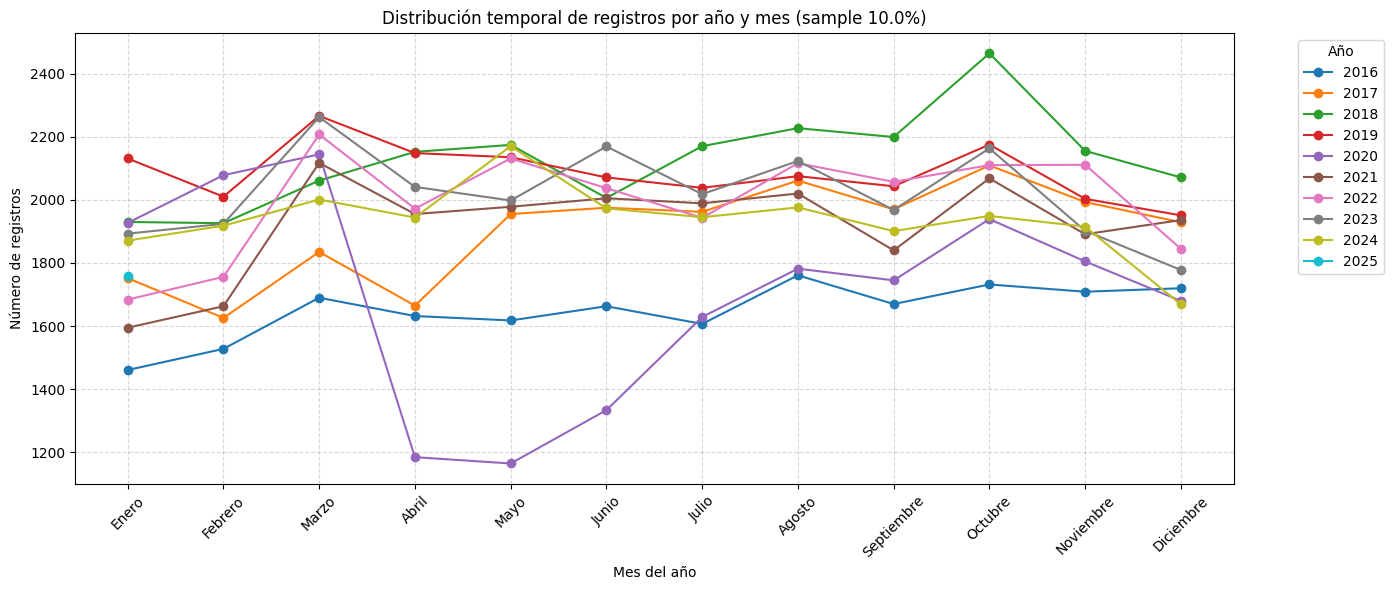

In [19]:
#Vamos a visualizar la distribución por año y por mes

# Primero calculamos el número de registros por año y mes
df_temp = (
    df_sample_anual.groupby(["anio_inicio", "mes_inicio"])
    .size()
    .reset_index(name="conteo")
)

# Aseguramos que los meses estén en orden cronológico
orden_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
               "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

df_temp["mes_inicio"] = pd.Categorical(df_temp["mes_inicio"], categories=orden_meses, ordered=True)

# Ordenamos el DataFrame por año y mes
df_temp = df_temp.sort_values(["anio_inicio", "mes_inicio"])

# Creamos el gráfico
plt.figure(figsize=(14, 6))

# Dibujamos líneas separadas por año
for anio in df_temp["anio_inicio"].unique():
    datos_anio = df_temp[df_temp["anio_inicio"] == anio]
    plt.plot(datos_anio["mes_inicio"], datos_anio["conteo"], marker="o", label=str(anio))

# Ajustes visuales
plt.title(f"Distribución temporal de registros por año y mes (sample {val_frac}%)")
plt.xlabel("Mes del año")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.legend(title="Año", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()


plt.show()

In [20]:
# Ya no necesitamos la columna ´categoria_delito´ antigua
# pues nos quedaremos con la versión simplificada (limpia) y nueva
df_sample_anual = df_sample_anual.drop(columns=["categoria_delito"])

# Renombramos la columna simplificada a 'categoria_delito'
df_sample_anual = df_sample_anual.rename(columns={"categoria_delito_simplificada": "categoria_delito"})

# Confirmamos los cambios
print("\nColumnas actuales del DataFrame:")
print(df_sample_anual.columns.tolist())



Columnas actuales del DataFrame:
['anio_inicio', 'mes_inicio', 'fecha_inicio', 'hora_inicio', 'anio_hecho', 'mes_hecho', 'fecha_hecho', 'hora_hecho', 'delito', 'competencia', 'fiscalia', 'agencia', 'unidad_investigacion', 'colonia_hecho', 'colonia_catalogo', 'alcaldia_hecho', 'alcaldia_catalogo', 'municipio_hecho', 'latitud', 'longitud', 'categoria_delito']


In [21]:
df_sample_anual

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito
59531,2016,Mayo,2016-05-10,00:00:00,2016.0,Abril,2016-04-03,12:28:00,AMENAZAS,<NA>,INVESTIGACIÓN EN COYOACÁN,COY-1,UI-1CD,CULHUACÁN CTM SECCIÓN V,Culhuacan Ctm Seccion I,COYOACAN,<NA>,CDMX,19.33182,-99.11862,delito de bajo impacto
63366,2016,Mayo,2016-05-18,00:00:00,2016.0,Mayo,2016-05-18,15:10:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-3CD,DOCTORES,Doctores,CUAUHTEMOC,<NA>,CDMX,19.4248,-99.14254,delito de bajo impacto
86409,2016,Julio,2016-07-07,00:00:00,2016.0,Mayo,2016-05-16,02:00:00,ROBO DE OBJETOS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-2SD,SANTA MARIA LA RIBERA,Santa Maria La Ribera,CUAUHTEMOC,<NA>,CDMX,19.44337,-99.15801,delito de bajo impacto
1036,2016,Enero,2016-01-04,00:00:00,2016.0,Enero,2016-01-04,15:30:00,PERDIDA DE LA VIDA POR OTRAS CAUSAS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-8,UI-3CD,ESPERANZA,Esperanza,CUAUHTEMOC,<NA>,CDMX,19.42177,-99.12674,hecho no delictivo
1240972,2016,Febrero,2016-02-08,00:00:00,2016.0,Febrero,2016-02-01,14:00:00,VIOLENCIA FAMILIAR,<NA>,INVESTIGACIÓN EN XOCHIMILCO,XO-2,UI-2SD,LA JOYA,<NA>,XOCHIMILCO,<NA>,CDMX,19.231226,-99.095951,delito de bajo impacto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2098399,2025,Enero,2025-01-31 16:25:45,16:25:45:00,2025.0,Enero,2025-01-31 14:00:00,14:00:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-5,UI-1SD,PEDREGAL DE AMINCO,Pueblo San Francisco Tlalnepantla,TLALPAN,<NA>,CDMX,19.201846,-99.131102,delito de bajo impacto
2081672,2025,Enero,2025-01-02 17:56:48,17:56:48:00,2025.0,Enero,2025-01-02 14:58:00,14:58:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,TLP-3,UI-1CD,SAN MIGUEL TOPILEJO,Pueblo San Miguel Topilejo,TLALPAN,<NA>,CDMX,19.191853,-99.141353,delito de bajo impacto
2083208,2025,Enero,2025-01-06 02:13:04,02:13:04:00,2024.0,Diciembre,2024-12-17 06:00:00,06:00:00:00,ROBO A PASAJERO A BORDO DE METRO SIN VIOLENCIA,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-A,UI-1SD,SANTA MARIA NONOALCO,Santa Maria Nonoalco,BENITO JUAREZ,<NA>,CDMX,19.384536,-99.186575,OTRAS
2092431,2025,Enero,2025-01-21 23:51:01,23:51:01:00,2022.0,Enero,2022-01-01 12:00:00,12:00:00:00,DESPOJO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN COYOACÁN,COY-1,UI-2CD,ROMERO DE TERREROS,Romero De Terreros,COYOACAN,<NA>,CDMX,19.343661,-99.168056,delito de bajo impacto


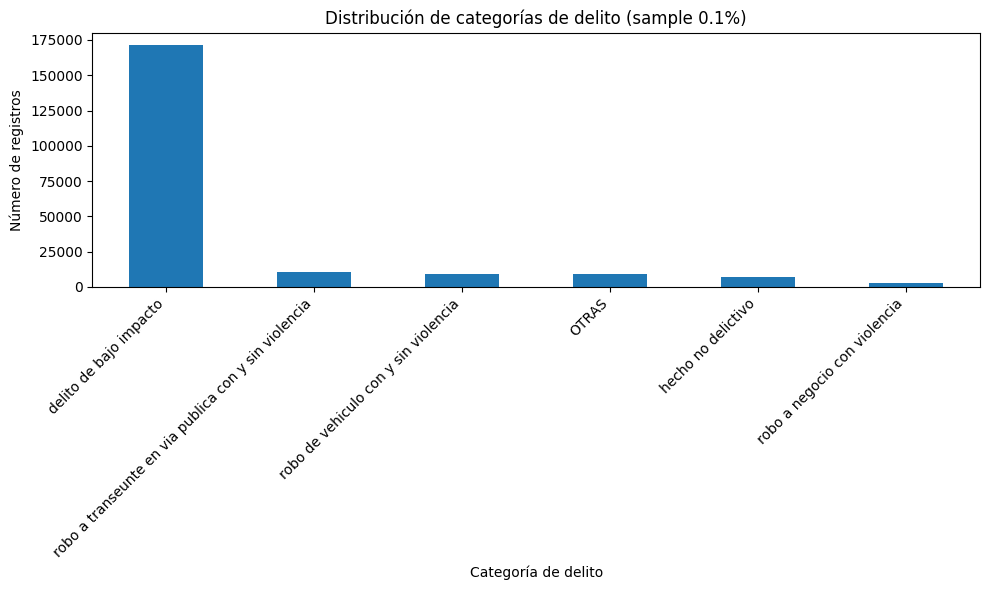

In [22]:
# Visualizamos la distribución de clases

# Calculamos el conteo por clase
conteos = df_sample_anual["categoria_delito"].value_counts().sort_values(ascending=False)

# Creamos el gráfico
plt.figure(figsize=(10, 6))
conteos.plot(kind="bar")

# Agregamos títulos y etiquetas
plt.title(f"Distribución de categorías de delito (sample {SAMPLE_FRAC}%)")
plt.xlabel("Categoría de delito")
plt.ylabel("Número de registros")
plt.xticks(rotation=45, ha='right')

# Mostramos el gráfico
plt.tight_layout()
plt.show()

# **7. EXPORTACIÓN**

In [23]:
# # Definimos el nombre del archivo de salida
nombre_archivo = "delitos_cdmx_sample_final.csv"

# Exportamos a CSV sin índice
df_sample_anual.to_csv(BASE_DIR + "data/"+nombre_archivo, index=False, encoding="utf-8")

print(f"\nArchivo exportado correctamente: {nombre_archivo}")
print(f"Tamaño final del dataset: {df_sample_anual.shape}")


Archivo exportado correctamente: delitos_cdmx_sample_final.csv
Tamaño final del dataset: (209873, 21)
